In [1]:
# PyTorch + CUDA 12.1 (suele encajar con Colab actual)
!pip -q install torch torchvision

# Clonar MedSAM2 e instalar en modo editable
!git clone https://github.com/bowang-lab/MedSAM2.git
%cd MedSAM2
!pip -q install -e ".[dev]"

# Descargar checkpoints oficiales
!bash download.sh


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
fatal: destination path 'MedSAM2' already exists and is not an empty directory.
/Users/jlguaza/Documents/tesis/MedSAM2

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1315  100  1315    0     0   2249      0 --:--:-- --:--:-- --:--:--  2247
100  148M  100  148M    0     0  48.2M      0  0:00:03  0:00:03 --:--:-- 61.2M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1325  100  1325    0     0   7292      0 --:--:-- --:--:-- --:--:--  7320
100  148M  100  148M    0     0  51.7M      0  0:00:02  0:00:02 --:--:-- 56.3M
  % Total    % Received % Xferd

In [8]:
XRAY_PNG_PATH = "../data/xray/CHNCXR_0160_0.png"
SUNNYBROOK_PNG_PATH = "../data/sunnybrook/SCD0000101_CINESAX_300.png"

In [7]:
%cd MedSAM2/

[Errno 2] No such file or directory: 'MedSAM2/'
/Users/jlguaza/Documents/tesis/MedSAM2


In [4]:
import torch, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

import glob, os, pprint
ckpts = glob.glob("checkpoints/*.pt") + glob.glob("checkpoints/*.pth")
pprint.pp(ckpts)

CKPT_PATH = "checkpoints/MedSAM2_latest.pt"  # Modificar para cambiar de modelo
print("CKPT_PATH: ", CKPT_PATH)

# Selección del YAML de configuración
# Para inferencia 2D con un PNG, un hiera_t (tiny) es suficiente para la demo.
CFG_PATH = "configs/sam2.1_hiera_t512.yaml"  # ajusta si usas otro (p. ej., sam2/configs/sam2.1_hiera_tiny.yaml)

# Construir predictor
sam2_model = build_sam2(CFG_PATH, CKPT_PATH, device="cuda" if torch.cuda.is_available() else "cpu")
predictor = SAM2ImagePredictor(sam2_model)

['checkpoints/MedSAM2_MRI_LiverLesion.pt',
 'checkpoints/MedSAM2_US_Heart.pt',
 'checkpoints/sam2.1_hiera_tiny.pt',
 'checkpoints/MedSAM2_CTLesion.pt',
 'checkpoints/efficienttam_s_512x512.pt',
 'checkpoints/MedSAM2_latest.pt',
 'checkpoints/efficienttam_ti_512x512.pt',
 'checkpoints/MedSAM2_2411.pt']
CKPT_PATH:  checkpoints/MedSAM2_latest.pt


In [5]:
# Cargar imagen PNG
xray_image_pil = Image.open(XRAY_PNG_PATH).convert("RGB")
sunnybrook_image_pil = Image.open(SUNNYBROOK_PNG_PATH).convert("RGB")

xray_image_np = np.array(xray_image_pil)
sunnybrook_image_np = np.array(sunnybrook_image_pil)

## Segmentacion por Puntos

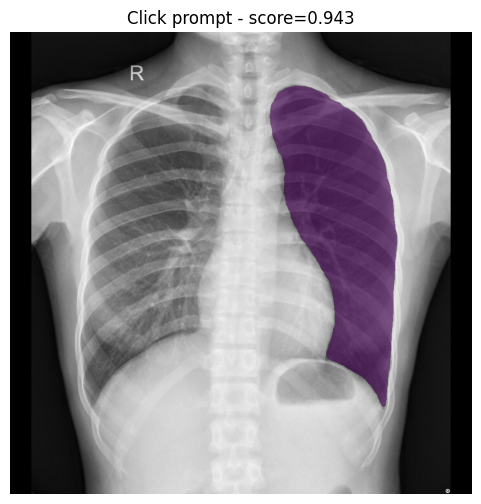

In [16]:
# Selecciono la imagen con la que quiero trabajar
image_np = xray_image_np

# Preparar imagen en el predictor
predictor.set_image(image_np)

# Un punto (x, y) en coordenadas de imagen (col, fila)
# Ejemplo: el centro de la imagen
h, w = image_np.shape[:2]
point = np.array([[(w//4)*3, h//2]])    # (N, 2)
label = np.array([1], dtype=np.int32)  # 1 = positivo, 0 = negativo

masks, scores, logits = predictor.predict(
    point_coords=point,
    point_labels=label,
    multimask_output=True  # devuelve varias hipótesis
)

# Elegimos la máscara con mejor score
best_idx = int(np.argmax(scores))
mask = masks[best_idx]

# Convertir a booleano si es necesario
mask_bool = mask.astype(bool)

# Visualizar
plt.figure(figsize=(6,6))
plt.imshow(image_np)
plt.imshow(np.ma.masked_where(~mask_bool, mask_bool), alpha=0.6)  # overlay semitransparente
plt.axis('off')
plt.title(f"Click prompt - score={scores[best_idx]:.3f}")
plt.show()

# Guardar la máscara y el overlay
# Image.fromarray((mask*255).astype(np.uint8)).save("mask_click.png")
# overlay = (0.4*image_np + 0.6*np.dstack([mask*255, np.zeros_like(mask), np.zeros_like(mask)])).astype(np.uint8)
# Image.fromarray(overlay).save("overlay_click.png")
# print("Guardado: mask_click.png y overlay_click.png")

### Auto-Mask casero prompteando varias veces con muchos puntos distintos

Ya se escanearon 0 de 100 puntos.
Ya se escanearon 10 de 100 puntos.
Ya se escanearon 20 de 100 puntos.
Ya se escanearon 30 de 100 puntos.
Ya se escanearon 40 de 100 puntos.
Ya se escanearon 50 de 100 puntos.
Ya se escanearon 60 de 100 puntos.
Ya se escanearon 70 de 100 puntos.
Ya se escanearon 80 de 100 puntos.
Ya se escanearon 90 de 100 puntos.
Puntos muestreados: 10 x 10 = 100
Candidatos tras umbrales: 63  |  Tras NMS: 2


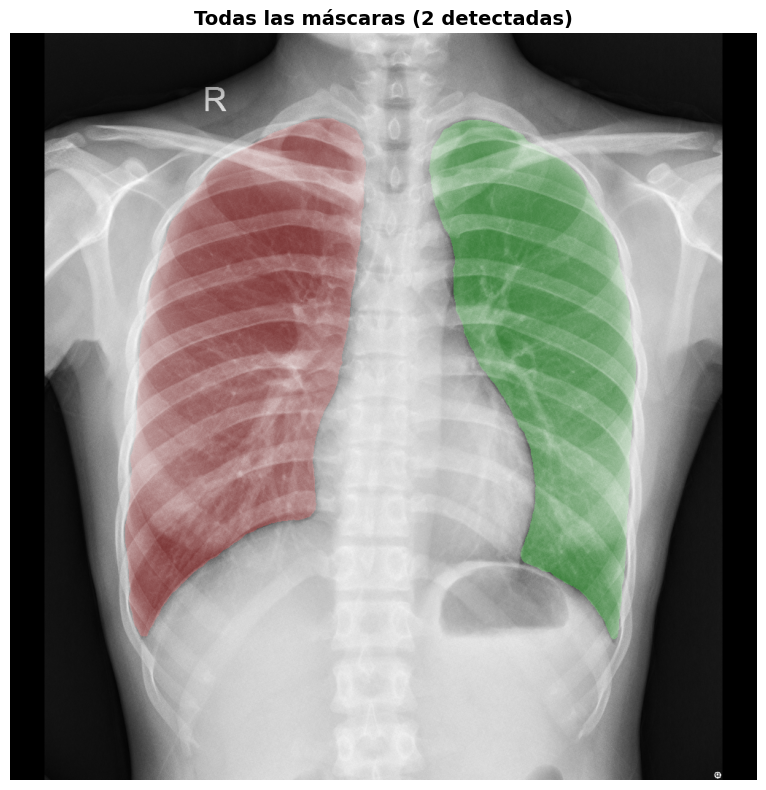

In [6]:
import numpy as np, json, math
import matplotlib.pyplot as plt
from PIL import Image

# Selecciono la imagen con la que quiero trabajar
image_np = xray_image_np

# === Parámetros "ligeros" para Colab ===
GRID_PTS     = 10      # ↓ sube/baja densidad (p.ej. 8, 10, 12)
SCORE_MIN    = 0.78    # ↓ relaja si filtra de más (p.ej. 0.80, 0.78)
AREA_FRAC    = 0.001   # ↓ permite objetos más chicos (p.ej. 0.0006)
IOU_NMS      = 0.55    # ↓ menos supresión (p.ej. 0.5, 0.45)
TOPK_PREVIEW = 20      # cantidad de máscaras a mostrar en grid

# === Utilidades ===
def iou_mask(a, b):
    inter = np.logical_and(a, b).sum()
    uni   = np.logical_or(a, b).sum()
    return inter / (uni + 1e-8)

def nms_by_iou(masks, scores, iou_thr=0.5):
    if not masks:
        return []
    order = np.argsort(scores)[::-1]
    masks  = [masks[i] for i in order]
    scores = [scores[i] for i in order]
    kept = []
    suppressed = np.zeros(len(masks), dtype=bool)
    for i in range(len(masks)):
        if suppressed[i]:
            continue
        kept.append((masks[i], scores[i]))
        for j in range(i+1, len(masks)):
            if suppressed[j]:
                continue
            if iou_mask(masks[i], masks[j]) >= iou_thr:
                suppressed[j] = True
    return kept

def grid_points(W, H, grid_pts):
    xs = np.linspace(W*0.02, W*0.98, grid_pts).astype(int)
    ys = np.linspace(H*0.02, H*0.98, grid_pts).astype(int)
    return [(x,y) for y in ys for x in xs]

def predict_point(predictor, image_np, x, y, multimask_output=True):
    pts = np.array([[int(x), int(y)]], dtype=np.int32)
    lbl = np.array([1], dtype=np.int32)
    masks, scores, _ = predictor.predict(
        point_coords=pts,
        point_labels=lbl,
        multimask_output=multimask_output
    )
    return masks, scores

# === Correr el automask "simple" ===
# image_pil = Image.open(PNG_PATH).convert("RGB")
# image_np  = np.array(image_pil)
H, W = image_np.shape[:2]
AREA_MIN = max(50, int(AREA_FRAC * H * W))

predictor.set_image(image_np)

cand_masks, cand_scores = [], []
pts = grid_points(W, H, GRID_PTS)
for idx, (x, y) in enumerate(pts):
    if idx % 10 == 0:
        print(f"Ya se escanearon {idx} de {len(pts)} puntos.")
    msks, scs = predict_point(predictor, image_np, x, y, multimask_output=True)
    for m, s in zip(msks, scs):
        if float(s) >= SCORE_MIN and int(m.sum()) >= AREA_MIN:
            cand_masks.append(m.astype(bool))
            cand_scores.append(float(s))

kept = nms_by_iou(cand_masks, cand_scores, iou_thr=IOU_NMS)
print(f"Puntos muestreados: {GRID_PTS} x {GRID_PTS} = {GRID_PTS*GRID_PTS}")
print(f"Candidatos tras umbrales: {len(cand_masks)}  |  Tras NMS: {len(kept)}")

if not kept:
    print("No se retuvieron máscaras. Sugerencias: baja SCORE_MIN o AREA_FRAC; o sube GRID_PTS.")
else:
    masks, scores = zip(*kept)
    masks, scores = list(masks), list(scores)

    # Ordenar por área*score (desc)
    order = np.argsort([-m.sum()*s for m,s in zip(masks, scores)])
    masks = [masks[i] for i in order]
    scores = [scores[i] for i in order]

    # === VISUALIZACIÓN 1: Overlay múltiple (todas las máscaras juntas) ===
    plt.figure(figsize=(12, 8))
    multi = image_np.copy().astype(np.float32)
    for i, m in enumerate(masks):
        c = i % 3  # canal 0,1,2 (RGB)
        ch = multi[:,:,c]
        ch = np.clip(ch*(1.0 - 0.35*m) + 255.0*(0.35*m), 0, 255)
        multi[:,:,c] = ch
    multi = multi.astype(np.uint8)
    plt.imshow(multi)
    plt.axis('off')
    plt.title(f'Todas las máscaras ({len(masks)} detectadas)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Efficient TAM

In [ ]:
import torch, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from efficient_track_anything.build_efficienttam import build_efficienttam
from efficient_track_anything.efficienttam_image_predictor import EfficientTAMImagePredictor

import glob, os, pprint
ckpts = glob.glob("checkpoints/*.pt") + glob.glob("checkpoints/*.pth")
pprint.pp(ckpts)

CKPT_PATH = "checkpoints/MedSAM2_latest.pt"  # Modificar para cambiar de modelo
print("CKPT_PATH: ", CKPT_PATH)

# Selección del YAML de configuración
# Para inferencia 2D con un PNG, un hiera_t (tiny) es suficiente para la demo.
CFG_PATH = "configs/sam2.1_hiera_t512.yaml"  # ajusta si usas otro (p. ej., sam2/configs/sam2.1_hiera_tiny.yaml)

# Construir predictor
sam2_model = build_sam2(CFG_PATH, CKPT_PATH, device="cuda" if torch.cuda.is_available() else "cpu")
predictor = SAM2ImagePredictor(sam2_model)

# Cargar imagen PNG
image_pil = Image.open(PNG_PATH).convert("RGB")
image_np = np.array(image_pil)

# Preparar imagen en el predictor
predictor.set_image(image_np)


## Segmentacion por Cajas

TypeError: ufunc 'invert' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

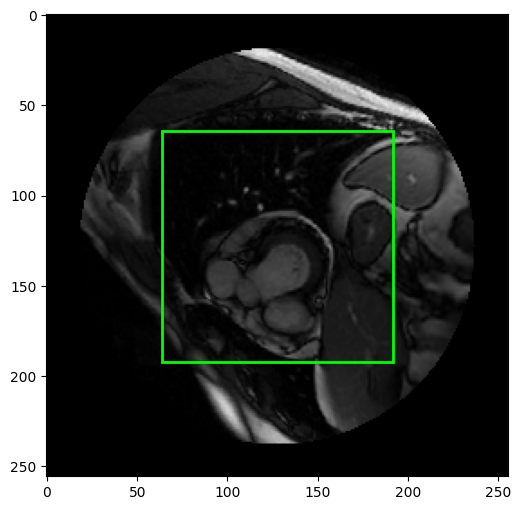

In [15]:
# Caja de ejemplo: un rectángulo central (ajústalo a tu objeto)
x0, y0 = int(0.25*w), int(0.25*h)
x1, y1 = int(0.75*w), int(0.75*h)
box = np.array([x0, y0, x1, y1])

masks, scores, logits = predictor.predict(
    box=box[None, :],  # shape (1, 4)
    multimask_output=True
)

best_idx = int(np.argmax(scores))
mask = masks[best_idx]

plt.figure(figsize=(6,6))
plt.imshow(image_np)
# dibujar caja
import matplotlib.patches as patches
ax = plt.gca()
rect = patches.Rectangle((x0, y0), x1-x0, y1-y0, linewidth=2, edgecolor='lime', facecolor='none')
ax.add_patch(rect)
plt.imshow(np.ma.masked_where(~mask, mask), alpha=0.6)
plt.axis('off')
plt.title(f"Box prompt - score={scores[best_idx]:.3f}")
plt.show()

Image.fromarray((mask*255).astype(np.uint8)).save("mask_box.png")
overlay = (0.4*image_np + 0.6*np.dstack([mask*255, np.zeros_like(mask), np.zeros_like(mask)])).astype(np.uint8)
Image.fromarray(overlay).save("overlay_box.png")
print("Guardado: mask_box.png y overlay_box.png")
